<a href="https://colab.research.google.com/github/PrachiKumar298/CRISPR-gRNA-Efficinecy/blob/main/clsa_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLSA v3 — Improvements (uses saved clsa_v2.keras)

**Time-saving version:** loads the saved 20-mer CLSA v2 model from Google Drive instead of retraining it.

Two improvements tested:
1. **22-mer flanking nucleotides** — adds positions 0 and 21 (PAM-flanking context)
2. **5-fold stratified CV** — rigorous evaluation with mean ± std for reviewers

What actually trains here:
- ✅ 22-mer CLSA v2 (new model, must train — ~1.5 hrs)
- ✅ 5-fold CV on 22-mer (5 fresh models — ~6 hrs)
- ⏭ 20-mer CLSA v2 → **loaded from clsa_v2.keras (saved)**
- ⏭ Baseline CNN retrain → **skipped, uses clsa_v2_preds.npy + baseline from saved run**


In [1]:
# =====================================================================
# CELL 1 — Setup + mount Drive
# =====================================================================
!pip install lightgbm xgboost -q
import os
if not os.path.exists('/content/DeepHF'):
    !wget -q https://github.com/tranmanh2004/DeepHF/archive/refs/heads/main.zip
    !unzip -q main.zip && mv DeepHF-main DeepHF
    print('Repo downloaded')
else:
    print('Repo already present')

from google.colab import drive
drive.mount('/content/drive')

# ── Point these to wherever you saved outputs ──
# If you saved to 'CLSA_v2_Outputs' as the original notebook did:
SAVED_MODEL_PATH = '/content/drive/My Drive/CLSA_v2_Outputs/clsa_v2.keras'
SAVED_PREDS_PATH = '/content/drive/My Drive/CLSA_v2_Outputs/clsa_v2_preds.npy'
SAVE_OUTPUT_DIR  = '/content/drive/My Drive/CLSA_improvements'

# Verify files exist
for p in [SAVED_MODEL_PATH, SAVED_PREDS_PATH]:
    status = '✓ found' if os.path.exists(p) else '✗ NOT FOUND — update path above'
    print(f'{status}: {p}')

Repo downloaded
Mounted at /content/drive
✓ found: /content/drive/My Drive/CLSA_v2_Outputs/clsa_v2.keras
✓ found: /content/drive/My Drive/CLSA_v2_Outputs/clsa_v2_preds.npy


In [2]:
# =====================================================================
# CELL 2 — Imports
# =====================================================================
import pickle, warnings, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy.stats import spearmanr, ttest_rel, wilcoxon
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

N_BASES      = 5
CAS9_SHAPE   = (3,)
THERMO_SHAPE = (11,)
VARIANT_IDX  = {'WT': 0, 'eSpCas9': 1, 'HF1': 2}
inv_map      = {0: 'WT', 1: 'eSpCas9', 2: 'HF1'}
INT_TO_BASE  = {1:'A', 2:'T', 3:'C', 4:'G', 5:'N'}
BASE_ONEHOT  = {'A':[1,0,0,0,0],'T':[0,1,0,0,0],
                'C':[0,0,1,0,0],'G':[0,0,0,1,0],'N':[0,0,0,0,1]}
DATA_DIR     = Path('/content/DeepHF/data')
VARIANT_FILES = {'WT':      DATA_DIR/'wt_seq_data_array.pkl',
                 'eSpCas9': DATA_DIR/'esp_seq_data_array.pkl',
                 'HF1':     DATA_DIR/'hf_seq_data_array.pkl'}
print('Imports OK  |  TF', tf.__version__)

Imports OK  |  TF 2.19.0


In [3]:
# =====================================================================
# CELL 3 — Data loader (20-mer AND 22-mer)
# =====================================================================
def load_variant(path, vid, seq_len=20):
    with open(path, 'rb') as f:
        try:    raw = pickle.load(f, encoding='latin1')
        except: raw = pickle.load(f)
    int_seqs = raw[0]   # (N, 22)
    thermo   = raw[1]   # (N, 11)
    eff      = raw[2]   # (N,)
    # Key change: 22-mer uses positions 0-21 (adds flanking nt)
    guide_ints = int_seqs[:, 0:22] if seq_len == 22 else int_seqs[:, 1:21]
    N    = len(guide_ints)
    seqs = [''.join(INT_TO_BASE.get(int(b),'N') for b in row) for row in guide_ints]
    oh   = np.array([[BASE_ONEHOT[b] for b in s] for s in seqs], dtype=np.float32)
    cas9 = np.zeros((N, 3), dtype=np.float32); cas9[:, vid] = 1.0
    return oh, cas9, eff.astype(np.float32), thermo.astype(np.float32)

def build_dataset(seq_len=20):
    seqs, cas9s, effs, thermos = [], [], [], []
    for vname, vpath in VARIANT_FILES.items():
        s, c, e, t = load_variant(vpath, VARIANT_IDX[vname], seq_len=seq_len)
        seqs.append(s); cas9s.append(c); effs.append(e); thermos.append(t)
    X_seq    = np.concatenate(seqs,    axis=0)
    X_cas9   = np.concatenate(cas9s,   axis=0)
    X_thermo = np.concatenate(thermos, axis=0)
    y        = np.concatenate(effs,    axis=0)
    vl       = X_cas9.argmax(axis=1)
    print(f'seq_len={seq_len}: {X_seq.shape}  thermo {X_thermo.shape}  y {y.shape}')
    return X_seq, X_cas9, X_thermo, y, vl

Xs20, Xc20, Xt20, y20, vl20 = build_dataset(seq_len=20)
Xs22, Xc22, Xt22, y22, vl22 = build_dataset(seq_len=22)

seq_len=20: (171109, 20, 5)  thermo (171109, 11)  y (171109,)
seq_len=22: (171109, 22, 5)  thermo (171109, 11)  y (171109,)


In [4]:
# =====================================================================
# CELL 4 — Splits (identical seed → same test indices for both lengths)
# =====================================================================
def make_split(Xs, Xc, Xt, y, vl):
    return train_test_split(
        Xs, Xc, Xt, y, vl,
        test_size=0.2, random_state=SEED, stratify=vl
    )

(Xs20_tr, Xs20_te, Xc20_tr, Xc20_te,
 Xt20_tr, Xt20_te, y20_tr,  y20_te,
 vl20_tr, vl20_te) = make_split(Xs20, Xc20, Xt20, y20, vl20)

(Xs22_tr, Xs22_te, Xc22_tr, Xc22_te,
 Xt22_tr, Xt22_te, y22_tr,  y22_te,
 vl22_tr, vl22_te) = make_split(Xs22, Xc22, Xt22, y22, vl22)

# Sanity check: same split → same labels
assert np.allclose(y20_te, y22_te), 'Label mismatch — splits diverged'
print(f'Train {len(y20_tr):,}  |  Test {len(y20_te):,}')
print('Splits verified: 20-mer and 22-mer test labels match ✓')

Train 136,887  |  Test 34,222
Splits verified: 20-mer and 22-mer test labels match ✓


In [5]:
# =====================================================================
# CELL 5 — Load saved 20-mer CLSA v2  (NO RETRAINING)
# =====================================================================
print('Loading saved CLSA v2 (20-mer)...')
model_20 = keras.models.load_model(SAVED_MODEL_PATH, safe_mode=False)
print(f'Loaded: {SAVED_MODEL_PATH}')
print(f'Model name: {model_20.name}  |  params: {model_20.count_params():,}')

# Option A: load saved predictions directly (fastest)
if os.path.exists(SAVED_PREDS_PATH):
    pred20 = np.load(SAVED_PREDS_PATH)
    print(f'Loaded saved predictions from {SAVED_PREDS_PATH}')
    # Verify shape matches test set
    assert len(pred20) == len(y20_te), (
        f'Prediction length {len(pred20)} != test set {len(y20_te)}. '
        'If the splits differ, set RERUN_20MER_INFERENCE=True below.'
    )
else:
    # Option B: re-run inference only (fast, ~30s)
    print('Predictions file not found — running inference on saved model...')
    pred20 = model_20.predict(
        [Xs20_te, Xc20_te, Xt20_te], batch_size=1024, verbose=1
    ).ravel()

# Compute metrics from loaded predictions
r2_20  = r2_score(y20_te, pred20)
rho_20 = spearmanr(y20_te, pred20)[0]
print(f'\n20-mer CLSA v2 (loaded):  R²={r2_20:.4f}  ρ={rho_20:.4f}')
print('(should match prior run: R²=0.8645  ρ=0.9273)')

Loading saved CLSA v2 (20-mer)...
Loaded: /content/drive/My Drive/CLSA_v2_Outputs/clsa_v2.keras
Model name: CLSA_v2  |  params: 208,737
Loaded saved predictions from /content/drive/My Drive/CLSA_v2_Outputs/clsa_v2_preds.npy

20-mer CLSA v2 (loaded):  R²=0.8645  ρ=0.9273
(should match prior run: R²=0.8645  ρ=0.9273)


In [6]:
# =====================================================================
# CELL 6 — CLSA v2 builder (parametric seq_len, same architecture)
# =====================================================================
def build_clsa_v2(seq_len=20, k=None,
                  lstm_units=64, num_heads=4, key_dim=16,
                  proj_dim=64,   thermo_dim=32,
                  dropout_main=0.4, dropout_merge=0.3):
    """
    seq_len=20 → original (k defaults to 10)
    seq_len=22 → flanking nt added (k defaults to 12,
                 covering the same biological region as k=10 on the 20-mer)
    """
    if k is None:
        k = 10 if seq_len == 20 else 12

    SEQ_SHAPE  = (seq_len, N_BASES)
    seq_in     = keras.Input(shape=SEQ_SHAPE,    name='seq')
    cas9_in    = keras.Input(shape=CAS9_SHAPE,   name='cas9')
    thermo_in  = keras.Input(shape=THERMO_SHAPE, name='thermo')

    x = layers.Conv1D(128, 3, padding='same', activation='relu')(seq_in)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x_seed    = layers.Cropping1D(cropping=(seq_len - k, 0),
                                   name=f'seed_k{k}')(x)
    lstm_out  = layers.LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.1,
                             name='short_lstm')(x_seed)

    x_proj    = layers.Dense(proj_dim, use_bias=False, name='proj')(x)
    attn_out  = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=0.1, name='mhsa'
    )(x_proj, x_proj)
    attn_out  = layers.LayerNormalization()(x_proj + attn_out)
    ff        = layers.Dense(128, activation='relu')(attn_out)
    ff        = layers.Dense(proj_dim)(ff)
    ff        = layers.LayerNormalization()(attn_out + ff)
    attn_pool = layers.GlobalAveragePooling1D(name='attn_pool')(ff)

    thermo_enc = layers.Dense(thermo_dim, activation='relu',
                               name='thermo_enc')(thermo_in)
    thermo_enc = layers.Dense(thermo_dim, activation='relu')(thermo_enc)
    thermo_enc = layers.Dropout(0.1)(thermo_enc)

    cas9_enc  = layers.Dense(16, activation='relu', name='cas9_enc')(cas9_in)

    gate_input = layers.Concatenate(name='gate_input')([lstm_out, attn_pool])
    alpha      = layers.Dense(lstm_units, activation='sigmoid',
                               name='gate_alpha')(gate_input)
    fused = layers.Add(name='gated_fusion')([
        layers.Multiply()([alpha,
                           layers.Lambda(lambda t: t, name='lstm_pass')(lstm_out)]),
        layers.Multiply()([
            layers.Lambda(lambda a: 1.0 - a, name='one_minus_alpha')(alpha),
            layers.Lambda(lambda t: t,        name='attn_pass')(attn_pool)
        ])
    ])

    z = layers.Concatenate(name='merge')([fused, thermo_enc, cas9_enc])
    z = layers.Dense(128, activation='relu')(z)
    z = layers.Dropout(dropout_main)(z)
    z = layers.Dense(64,  activation='relu')(z)
    z = layers.Dropout(dropout_merge)(z)
    out = layers.Dense(1, activation='sigmoid')(z)

    return keras.Model(inputs=[seq_in, cas9_in, thermo_in],
                       outputs=out, name=f'CLSA_v2_{seq_len}mer')


def fit_model(model, Xs, Xc, Xt, y,
              epochs=150, batch_size=512, verbose=1):
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    cbs = [
        EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=0)
    ]
    return model.fit([Xs, Xc, Xt], y,
                     validation_split=0.1,
                     epochs=epochs, batch_size=batch_size,
                     callbacks=cbs, verbose=verbose)


def score(model, Xs, Xc, Xt, y, vl):
    yp = model.predict([Xs, Xc, Xt], batch_size=1024, verbose=0).ravel()
    d  = {'r2':  r2_score(y, yp),
          'rho': spearmanr(y, yp)[0],
          'mse': float(np.mean((y - yp)**2))}
    for vid, vname in inv_map.items():
        m = vl == vid
        d[f'{vname}_r2']  = r2_score(y[m], yp[m])
        d[f'{vname}_rho'] = spearmanr(y[m], yp[m])[0]
    return d, yp

print(f'22-mer model params: {build_clsa_v2(seq_len=22).count_params():,}')

22-mer model params: 208,737


In [11]:
# =====================================================================
# CELL 7 — Train 22-mer CLSA v2  (Improvement 1 — must train)
# =====================================================================
print('Training 22-mer CLSA v2 (new — must train)...')
model_22 = build_clsa_v2(seq_len=22)
hist_22  = fit_model(model_22,
                     Xs22_tr, Xc22_tr, Xt22_tr, y22_tr,
                     epochs=150, verbose=1)

res22, pred22 = score(model_22,
                      Xs22_te, Xc22_te, Xt22_te,
                      y22_te, vl22_te)

print(f'\n22-mer CLSA v2:  R²={res22["r2"]:.4f}  ρ={res22["rho"]:.4f}')
print(f'20-mer CLSA v2:  R²={r2_20:.4f}  ρ={rho_20:.4f}  (loaded)')
print(f'Delta:          ΔR²={res22["r2"]-r2_20:+.4f}  Δρ={res22["rho"]-rho_20:+.4f}')

Training 22-mer CLSA v2 (new — must train)...
Epoch 1/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 151s 582ms/step - loss: 0.0468 - mae: 0.1615 - val_loss: 0.0462 - val_mae: 0.1656 - learning_rate: 0.0010
Epoch 2/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 135s 560ms/step - loss: 0.0189 - mae: 0.1054 - val_loss: 0.0269 - val_mae: 0.1259 - learning_rate: 0.0010
Epoch 3/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 136s 564ms/step - loss: 0.0166 - mae: 0.0987 - val_loss: 0.0161 - val_mae: 0.0957 - learning_rate: 0.0010
Epoch 4/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 135s 562ms/step - loss: 0.0152 - mae: 0.0942 - val_loss: 0.0140 - val_mae: 0.0889 - learning_rate: 0.0010
Epoch 5/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 136s 564ms/step - loss: 0.0142 - mae: 0.0910 - val_loss: 0.0131 - val_mae: 0.0864 - learning_rate: 0.0010
Epoch 6/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 135s 562ms/step - loss: 0.0133 - mae: 0.0881 - val_loss: 0.0126 - val_mae: 0.0846 - learning_rate: 0.0010
Epoch 7/150
241/241 ━━━━━━━━━━━━━━━━━━━━ 146s 577ms/step - loss: 0.0126 

In [8]:
# =====================================================================
# CELL 8 — 5-Fold CV on 22-mer  (Improvement 2 — must train)
# =====================================================================
N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
fold_preds   = []

# Create a directory to save fold-specific outputs
FOLD_SAVE_DIR = Path(SAVE_OUTPUT_DIR) / 'cv_folds'
FOLD_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'Saving fold outputs to: {FOLD_SAVE_DIR}')

# Generate all train/test indices upfront to ensure consistent iteration
all_splits = list(skf.split(np.zeros(len(y22)), vl22))

for fold_idx, (train_idx, test_idx) in enumerate(all_splits):

    current_fold_num = fold_idx + 1
    fold_model_path = FOLD_SAVE_DIR / f'fold_{current_fold_num}_model.keras'
    fold_res_path   = FOLD_SAVE_DIR / f'fold_{current_fold_num}_results.pkl'
    fold_pred_path  = FOLD_SAVE_DIR / f'fold_{current_fold_num}_preds.npy'

    print(f'\n{"="*55}')
    print(f'  Fold {current_fold_num}/{N_FOLDS}  '
          f'(train {len(train_idx):,}, test {len(test_idx):,})')
    print(f'{"="*55}')

    if fold_model_path.exists() and fold_res_path.exists() and fold_pred_path.exists():
        print(f'  Fold {current_fold_num} already completed. Loading saved results.')
        with open(fold_res_path, 'rb') as f:
            res_f = pickle.load(f)
        pred_f = np.load(fold_pred_path)
        print(f'  Loaded Fold {current_fold_num}: R²={res_f["r2"]:.4f}  '
              f'ρ={res_f["rho"]:.4f}')
    else:
        tf.random.set_seed(SEED + fold_idx) # Ensure different seeds for each fold
        model_f = build_clsa_v2(seq_len=22)
        hist_f  = fit_model(
            model_f,
            Xs22[train_idx], Xc22[train_idx], Xt22[train_idx], y22[train_idx],
            epochs=150, verbose=1
        )
        res_f, pred_f = score(
            model_f,
            Xs22[test_idx], Xc22[test_idx], Xt22[test_idx],
            y22[test_idx],  vl22[test_idx]
        )
        res_f['fold']       = current_fold_num
        # hist_f.history might be empty if early stopping triggered immediately
        if hist_f.history.get('val_loss'):
             res_f['best_epoch'] = int(np.argmin(hist_f.history['val_loss'])) + 1
        else:
             res_f['best_epoch'] = 1 # Fallback if no history (e.g., 1 epoch run)

        print(f'  Fold {current_fold_num}: R²={res_f["r2"]:.4f}  '
              f'ρ={res_f["rho"]:.4f}  (best epoch {res_f["best_epoch"]})')

        # Save model and results for this fold
        model_f.save(fold_model_path)
        with open(fold_res_path, 'wb') as f:
            pickle.dump(res_f, f)
        np.save(fold_pred_path, pred_f)
        print(f'  Saved outputs for Fold {current_fold_num} to {FOLD_SAVE_DIR}')

        del model_f
        tf.keras.backend.clear_session()

    fold_results.append(res_f)
    fold_preds.append((y22[test_idx], pred_f))

# After the loop, fold_results and fold_preds will contain data for all folds,
# either loaded or newly computed.

Saving fold outputs to: /content/drive/My Drive/CLSA_improvements/cv_folds

  Fold 1/5  (train 136,887, test 34,222)
  Fold 1 already completed. Loading saved results.
  Loaded Fold 1: R²=0.8704  ρ=0.9314

  Fold 2/5  (train 136,887, test 34,222)
  Fold 2 already completed. Loading saved results.
  Loaded Fold 2: R²=0.8648  ρ=0.9279

  Fold 3/5  (train 136,887, test 34,222)
  Fold 3 already completed. Loading saved results.
  Loaded Fold 3: R²=0.8675  ρ=0.9295

  Fold 4/5  (train 136,887, test 34,222)
  Fold 4 already completed. Loading saved results.
  Loaded Fold 4: R²=0.8656  ρ=0.9285

  Fold 5/5  (train 136,888, test 34,221)
  Fold 5 already completed. Loading saved results.
  Loaded Fold 5: R²=0.8663  ρ=0.9283


In [9]:
# =====================================================================
# CELL 9 — CV Summary
# =====================================================================
df_cv = pd.DataFrame(fold_results)

metrics = ['r2','rho','mse',
           'WT_r2','eSpCas9_r2','HF1_r2',
           'WT_rho','eSpCas9_rho','HF1_rho']
summary = {m: f'{df_cv[m].mean():.4f} ± {df_cv[m].std():.4f}' for m in metrics}

print('=== 5-Fold CV — 22-mer CLSA v2 ===')
for k_,v_ in summary.items():
    print(f'  {k_:18s}: {v_}')
print('\nPer-fold:')
print(df_cv[['fold','r2','rho','mse','best_epoch']].to_string(index=False))

df_cv.to_csv('cv_fold_results.csv', index=False)
pd.DataFrame([summary]).to_csv('cv_summary.csv', index=False)
print('\nSaved.')

=== 5-Fold CV — 22-mer CLSA v2 ===
  r2                : 0.8669 ± 0.0022
  rho               : 0.9291 ± 0.0014
  mse               : 0.0086 ± 0.0002
  WT_r2             : 0.8319 ± 0.0068
  eSpCas9_r2        : 0.7448 ± 0.0039
  HF1_r2            : 0.7891 ± 0.0062
  WT_rho            : 0.8910 ± 0.0033
  eSpCas9_rho       : 0.8752 ± 0.0029
  HF1_rho           : 0.8792 ± 0.0023

Per-fold:
 fold       r2      rho      mse  best_epoch
    1 0.870375 0.931369 0.008423          82
    2 0.864771 0.927924 0.008793          73
    3 0.867547 0.929483 0.008568          75
    4 0.865567 0.928451 0.008823          57
    5 0.866309 0.928293 0.008636          63

Saved.


In [16]:
# =====================================================================
# CELL 10 — Bootstrap: 22-mer CLSA v2 vs loaded 20-mer CLSA v2
#           Uses loaded pred20 — no retraining of baseline needed.
# =====================================================================
N_BOOT = 2000
rng    = np.random.default_rng(SEED)
boot_dr2, boot_drho = [], []

for _ in range(N_BOOT):
    idx = rng.choice(len(y22_te), size=len(y22_te), replace=True)
    boot_dr2.append(
        r2_score(y22_te[idx], pred22[idx]) -
        r2_score(y20_te[idx], pred20[idx])
    )
    boot_drho.append(
        spearmanr(y22_te[idx], pred22[idx])[0] -
        spearmanr(y20_te[idx], pred20[idx])[0]
    )

boot_dr2  = np.array(boot_dr2)
boot_drho = np.array(boot_drho)
ci_r2     = np.percentile(boot_dr2,  [2.5, 97.5])
ci_rho    = np.percentile(boot_drho, [2.5, 97.5])

t_stat, t_pval = ttest_rel((y22_te - pred22)**2, (y20_te - pred20)**2)
w_stat, w_pval = wilcoxon((y22_te - pred22)**2 - (y20_te - pred20)**2)

print('=== Bootstrap: 22-mer vs 20-mer CLSA v2 ===')
print(f'ΔR²  mean={boot_dr2.mean():+.4f}   95% CI [{ci_r2[0]:+.4f}, {ci_r2[1]:+.4f}]')
print(f'Δρ   mean={boot_drho.mean():+.4f}   95% CI [{ci_rho[0]:+.4f}, {ci_rho[1]:+.4f}]')
print(f'Paired t:   t={t_stat:.2f}  p={t_pval:.2e}')
print(f'Wilcoxon:   p={w_pval:.2e}')

if ci_r2[0] > 0:
    print('\n✓ 22-mer is SIGNIFICANTLY BETTER than 20-mer (CI entirely > 0)')
elif ci_r2[1] < 0:
    print('\n✗ 20-mer is still better — flanking nt did not help')
else:
    print('\n~ No significant difference (CI spans 0) — marginal benefit')

=== Bootstrap: 22-mer vs 20-mer CLSA v2 ===
ΔR²  mean=+0.0064   95% CI [+0.0041, +0.0087]
Δρ   mean=+0.0043   95% CI [+0.0030, +0.0056]
Paired t:   t=-5.69  p=1.25e-08
Wilcoxon:   p=4.31e-06

✓ 22-mer is SIGNIFICANTLY BETTER than 20-mer (CI entirely > 0)


In [13]:
# =====================================================================
# CELL 11 — Full comparison table
# =====================================================================
all_models = [
    {'Model': 'Baseline CNN',           'Split': '80/20',    'R2': 0.8549, 'Rho': 0.9220},
    {'Model': 'CLSA v1 (k=5)',          'Split': '80/20',    'R2': 0.8383, 'Rho': 0.9134},
    {'Model': 'CNN+LSTM k=10',          'Split': '80/20',    'R2': 0.8511, 'Rho': 0.9203},
    {'Model': 'CLSA v2 20-mer (loaded)','Split': '80/20',    'R2': r2_20,  'Rho': rho_20},
    {'Model': '★ CLSA v2 22-mer',       'Split': '80/20',    'R2': res22['r2'],       'Rho': res22['rho']},
    {'Model': '★★ CLSA v2 22-mer CV',  'Split': '5-fold CV',
     'R2': df_cv['r2'].mean(), 'Rho': df_cv['rho'].mean(),
     'R2_std': df_cv['r2'].std(), 'Rho_std': df_cv['rho'].std()},
]

df_all = pd.DataFrame(all_models).fillna('')
print(df_all.to_string(index=False))
df_all.to_csv('full_comparison_table.csv', index=False)

                  Model     Split       R2      Rho    R2_std   Rho_std
           Baseline CNN     80/20 0.854900 0.922000                    
          CLSA v1 (k=5)     80/20 0.838300 0.913400                    
          CNN+LSTM k=10     80/20 0.851100 0.920300                    
CLSA v2 20-mer (loaded)     80/20 0.864455 0.927343                    
       ★ CLSA v2 22-mer     80/20 0.870893 0.931652                    
   ★★ CLSA v2 22-mer CV 5-fold CV 0.866914 0.929104  0.002188  0.001392


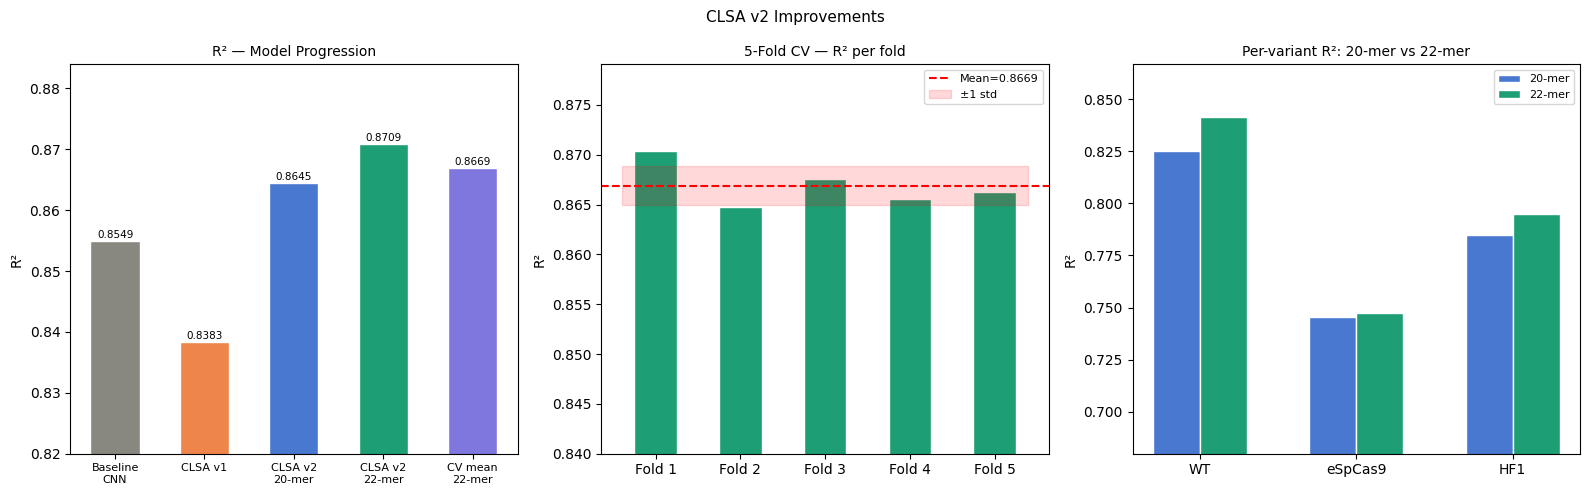

In [14]:
# =====================================================================
# CELL 12 — Plots
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# A: Model progression bar
labels = ['Baseline\nCNN', 'CLSA v1', 'CLSA v2\n20-mer', 'CLSA v2\n22-mer', 'CV mean\n22-mer']
r2s    = [0.8549, 0.8383, r2_20, res22['r2'], df_cv['r2'].mean()]
colors = ['#888780','#ee854a','#4878d0','#1D9E75','#7F77DD']
x = np.arange(len(labels))
bars = axes[0].bar(x, r2s, color=colors, width=0.55, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylim(0.82, max(r2s)*1.015)
axes[0].set_ylabel('R²'); axes[0].set_title('R² — Model Progression', fontsize=10)
for bar, v in zip(bars, r2s):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{v:.4f}', ha='center', fontsize=7.5)

# B: CV fold R² with std band
fold_r2s = df_cv['r2'].values
axes[1].bar(df_cv['fold'], fold_r2s, color='#1D9E75', width=0.5, edgecolor='white')
axes[1].axhline(fold_r2s.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean={fold_r2s.mean():.4f}')
axes[1].fill_between([0.6, N_FOLDS+0.4],
                      fold_r2s.mean()-fold_r2s.std(),
                      fold_r2s.mean()+fold_r2s.std(),
                      alpha=0.15, color='red', label='±1 std')
axes[1].set_xticks(df_cv['fold'])
axes[1].set_xticklabels([f'Fold {i}' for i in df_cv['fold']])
axes[1].set_ylim(0.84, max(fold_r2s)*1.01)
axes[1].set_ylabel('R²'); axes[1].set_title('5-Fold CV — R² per fold', fontsize=10)
axes[1].legend(fontsize=8)

# C: Per-variant 20-mer vs 22-mer
variants = ['WT', 'eSpCas9', 'HF1']
r2_20v   = [0.8250, 0.7457, 0.7847]  # from prior CLSA v2 run
r2_22v   = [res22['WT_r2'], res22['eSpCas9_r2'], res22['HF1_r2']]
xv = np.arange(len(variants)); w = 0.3
axes[2].bar(xv-w/2, r2_20v, width=w, color='#4878d0', label='20-mer', edgecolor='white')
axes[2].bar(xv+w/2, r2_22v, width=w, color='#1D9E75', label='22-mer', edgecolor='white')
axes[2].set_xticks(xv); axes[2].set_xticklabels(variants)
axes[2].set_ylim(0.68, max(r2_20v+r2_22v)*1.03)
axes[2].set_ylabel('R²'); axes[2].set_title('Per-variant R²: 20-mer vs 22-mer', fontsize=10)
axes[2].legend(fontsize=8)

plt.suptitle('CLSA v2 Improvements', fontsize=11)
plt.tight_layout()
plt.savefig('improvements_summary.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
# =====================================================================
# CELL 13 — Save all outputs to Drive
# =====================================================================
os.makedirs(SAVE_OUTPUT_DIR, exist_ok=True)

model_22.save('clsa_v2_22mer.keras')
np.save('clsa_v2_22mer_preds.npy', pred22)

files = [
    'clsa_v2_22mer.keras',
    'clsa_v2_22mer_preds.npy',
    'cv_fold_results.csv',
    'cv_summary.csv',
    'full_comparison_table.csv',
    'improvements_summary.pdf',
]
for f in files:
    if os.path.exists(f):
        shutil.copy(f, SAVE_OUTPUT_DIR)
        print(f'Saved: {f} → {SAVE_OUTPUT_DIR}')
    else:
        print(f'Not found (skipped): {f}')

Saved: clsa_v2_22mer.keras → /content/drive/My Drive/CLSA_improvements
Saved: clsa_v2_22mer_preds.npy → /content/drive/My Drive/CLSA_improvements
Saved: cv_fold_results.csv → /content/drive/My Drive/CLSA_improvements
Saved: cv_summary.csv → /content/drive/My Drive/CLSA_improvements
Saved: full_comparison_table.csv → /content/drive/My Drive/CLSA_improvements
Saved: improvements_summary.pdf → /content/drive/My Drive/CLSA_improvements
